In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import construction_helpers as ch # Needed for @ auto-alignment
import data_structure.Category as cat
import data_structure.Numeric as nm
import data_structure.Operators as ops
import data_structure.Term as fd
import websocket_transfer.capture as cap

Requesting render from server...
Received from server: {"msgType": "Connected"}


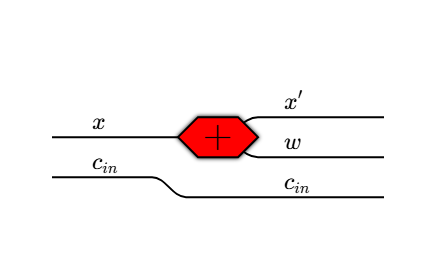

In [3]:
''' Convolution Matrix '''
convolution_reindexing = cat.StrideMorphism.from_matrix(
    (1, 1), 
    dom_names=("x'", 'w'),
    cod_names=('x',),
    name='+')
c_in_axis = fd.DynamicName('c', fd.DynamicName('in')).capture(cat.RawAxis())
convolution_matrix = (convolution_reindexing  * c_in_axis >> cat.Reals())
await cap.capture_morphism(convolution_matrix)

Requesting render from server...
Received from server: {"msgType": "Connected"}


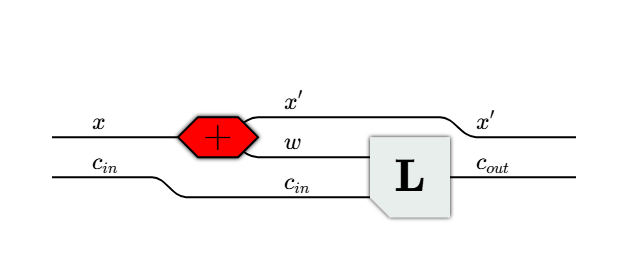

In [4]:
''' Full Convolution Expression '''
c_out = fd.DynamicName('c', fd.DynamicName('out')).capture(cat.RawAxis())
linear = ops.Linear.template(2, c_out)
convolution = convolution_matrix @ linear
await cap.capture_morphism(convolution)